# Treinamento CNN Pontinhos — V11 Colab **AddAug** (3,4M + 4,92M distintos novos)

Variante de adicao dirigida de dados sobre o BoxNet v4 base. Inclui:

- **3.423.460** amostras brutas dos 419 NPZs originais (mesmas usadas no v4 base)
- **4.915.970** amostras DISTINTAS NOVAS, dos NPZs `_refH`/`_refV`/`_r180`, que
  NAO existem nos originais (todas as t=1..30)
- **6.439** posições em que o diagnóstico da CNN Oráculo falhava. Estas amostras são injetadas em NPZ distinto `refinamento_oraculo_001.npz` e `refinamento_oraculo_002.npz` que contém as posição que falharam + suas posições de simetria. Posições adicionadas com Sample Weight

**Total: 8.364.778 amostras (~8,36M)**.

Default: `EXPERIMENTO = 'boxnetv4_oraculo_exato_refinamento2_8p3M'` · `batch_size = 2048` (batch menor p/ generalizacao mais limpa; um pouco mais lento que 4096).

In [1]:
# =========================================================================
# SETUP COLAB — montar Google Drive e instalar dependencia do relatorio
# =========================================================================
from google.colab import drive
drive.mount('/content/drive')
!pip -q install tabulate


Mounted at /content/drive


In [2]:
# =========================================================================
# CONFIGURACAO — Colab (BoxNet v4, base do oraculo (8,3M) + refinamentos)
# =========================================================================
import os

# >>> EDITE: pasta no Google Drive com a base do oraculo + refinamentos (108 NPZ) <<<
#     (dataset_pequeno_0001.npz ... _0152.npz, SEM sufixo _refH/_refV/_r180)
PASTA_NPZ     = '/content/drive/MyDrive/Arena Sagaz/CNN/dados/profundidade_oraculo_exato'
RESULTADO_DIR = '/content/drive/MyDrive/Arena Sagaz/CNN/resultados'
os.makedirs(RESULTADO_DIR, exist_ok=True)

# Usa só os NPZ originais (ignora variantes de simetria, caso existam na pasta).
SOMENTE_ORIGINAIS = True

# Tag do experimento — entra nos nomes de checkpoint/TFLite/relatorio.
# Troque a cada degrau da escada de ablacao para NAO sobrescrever resultados.
EXPERIMENTO = 'boxnetv4_oraculo_exato_refinamento2_8p3M'

# Canais a incluir no treinamento (12 canonicos da Fase A.2).
CANAIS_TREINAMENTO = [
    'aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita',
    'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta',
    'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta',
    'paridade_cadeia_longa_impar'
]

# 'INCLUI_DUPLICADAS' (todas as amostras) ou 'DISTINTAS' (apenas matrizes unicas)
UTILIZACAO_MATRIZES = 'INCLUI_DUPLICADAS'

# USE_SAMPLE_WEIGHT = True: aplica peso por qtd_tracos. False = sem peso.
USE_SAMPLE_WEIGHT = False

# Peso extra nas amostras do refinamento (estados novos do diagnostico) vs base.
# Moderado: alto demais => decora; baixo demais => diluido. Ajustavel.
PESO_REFINAMENTO = 12.0

print(f'PASTA_NPZ         = {PASTA_NPZ}')
print(f'RESULTADO_DIR     = {RESULTADO_DIR}')
print(f'SOMENTE_ORIGINAIS = {SOMENTE_ORIGINAIS}')
print(f'EXPERIMENTO       = {EXPERIMENTO}')
print(f'Canais ({len(CANAIS_TREINAMENTO)}): {CANAIS_TREINAMENTO}')

PASTA_NPZ         = /content/drive/MyDrive/Arena Sagaz/CNN/dados/profundidade_oraculo_exato
RESULTADO_DIR     = /content/drive/MyDrive/Arena Sagaz/CNN/resultados
SOMENTE_ORIGINAIS = True
EXPERIMENTO       = boxnetv4_oraculo_exato_refinamento2_8p3M
Canais (12): ['aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita', 'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta', 'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta', 'paridade_cadeia_longa_impar']


In [3]:
import os
import glob

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Colab T4: usa toda a VRAM da GPU com memory growth (sem limite fixo de 3 GB).
gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print(f"Aviso GPU config: {e}")

sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)
print("Dispositivos GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# =========================================================================
# CAPTURA DE RELATÓRIO — executar logo após a célula de imports
# rprint()        : imprime no terminal E grava no buffer do relatório .md.
# _md_h()         : cabeçalho markdown (## , ### …).
# _md_sep()       : linha separadora ---.
# _md_table()     : DataFrame → tabela markdown (requer tabulate, pré-instalado no Colab).
# _iniciar_secao(): reset de seção — re-execução segura de células individuais.
# =========================================================================
import io as _io_mod

_report_buf = _io_mod.StringIO()
_secao_pos: dict = {}  # checkpoint de posição no buffer por nome de seção

def rprint(*args, sep=' ', end='\n'):
    """Imprime no terminal e captura no buffer do relatório."""
    print(*args, sep=sep, end=end)
    msg = sep.join(str(a) for a in args) + end
    _report_buf.write(msg)

def _md_h(level: int, text: str):
    rprint('\n' + '#' * level + ' ' + text + '\n')

def _md_sep():
    rprint('\n---\n')

def _md_table(df, floatfmt='.4f', index=True):
    try:
        rprint(df.to_markdown(floatfmt=floatfmt, index=index))
    except Exception:
        rprint(df.to_string())
    rprint()

def _iniciar_secao(nome: str):
    """Volta ao checkpoint desta seção se ela já foi escrita antes.

    Permite re-executar qualquer célula de relatório sem duplicar conteúdo
    no buffer. Chame no início de cada célula que escreve no relatório.
    """
    if nome in _secao_pos:
        _report_buf.seek(_secao_pos[nome])
        _report_buf.truncate()
    _secao_pos[nome] = _report_buf.tell()

print('Captura de relatório ativada.')

Captura de relatório ativada.


In [5]:
# =========================================================================
# 1. LEITURA DOS DADOS
# =========================================================================
from datetime import datetime

# Ordem canonica dos 12 canais
NOMES_CANAIS_REF = (
    'aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita',
    'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta',
    'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta',
    'paridade_cadeia_longa_impar'
)

_canais_alvo = CANAIS_TREINAMENTO if CANAIS_TREINAMENTO is not None else list(NOMES_CANAIS_REF)
INDICES_CANAIS = [NOMES_CANAIS_REF.index(c) for c in _canais_alvo]
K = len(INDICES_CANAIS)
print(f'Canais para treino ({K}): {_canais_alvo}')
print(f'Indices no tensor (N,4,3,12): {INDICES_CANAIS}')

TRACOS_WEIGHTS = {
    1: 815.74,  2: 54.38,   3: 5.65,   4: 1.47,   5: 1.08,
    6: 1.02,    7: 1.01,    8: 1.00,   9: 1.00,   10: 1.00,
    11: 1.00,   12: 1.00,   13: 1.00,  14: 1.00,  15: 1.00,
    16: 1.00,   17: 1.00,   18: 1.01,  19: 1.03,  20: 1.07,
    21: 1.17,   22: 1.37,   23: 1.70,  24: 2.34,  25: 3.51,
    26: 6.32,   27: 14.58,  28: 41.05, 29: 150.52, 30: 815.74,
}

# =========================================================================
# 1.1 LEITURA DOS LOTES
# =========================================================================
arquivos_npz = sorted(glob.glob(os.path.join(PASTA_NPZ, '*.npz')))
if SOMENTE_ORIGINAIS:
    # Exclui as variantes de simetria (_refH/_refV/_r180), mas mantem
    # o arquivo extra `aug_distintos_novos_todos_t.npz` (gerado pelo
    # script de pre-processamento) — ele nao tem esses sufixos no nome.
    _suf = ('_refH', '_refV', '_r180')
    arquivos_npz = [a for a in arquivos_npz
                    if not any(s in os.path.basename(a) for s in _suf)]
print(f'Encontrados {len(arquivos_npz)} arquivos NPZ '
      f'(esperado: 105 + 1 (aug) + 2 (refinamentos) = 108).')

lista_estados, lista_canais = [], []
lista_rotulos, lista_scores, lista_qtd_tracos, lista_cadeias = [], [], [], []
lista_origem = []
labels_canonicos = None

for arquivo in arquivos_npz:
    dados = np.load(arquivo, allow_pickle=True)
    lista_estados.append(dados['estados'])
    lista_canais.append(dados['canais'])
    lista_rotulos.append(dados['melhor_jogada'])
    lista_scores.append(dados['score_melhor_jogada'])
    lista_qtd_tracos.append(dados['qtd_tracos'])
    lista_cadeias.append(dados['qtd_cadeias_longas'])
    lista_origem.append(np.full(len(dados['estados']), 'refinamento' in os.path.basename(arquivo).lower(), dtype=bool))
    if labels_canonicos is None:
        labels_canonicos = dados['labels_canonicos'].tolist()

estados_raw     = np.concatenate(lista_estados,    axis=0)
canais_raw      = np.concatenate(lista_canais,     axis=0)
y_str           = np.concatenate(lista_rotulos,    axis=0)
scores_raw      = np.concatenate(lista_scores,     axis=0)
qtd_tracos_all  = np.concatenate(lista_qtd_tracos, axis=0).astype(np.int8)
qtd_cadeias_all = np.concatenate(lista_cadeias,    axis=0).astype(np.int8)
origem_refinamento = np.concatenate(lista_origem)

print(f'Total de amostras brutas: {len(canais_raw):,}')
_n_amostras_total = len(canais_raw)

# =========================================================================
# 1.2 FILTRAGEM DE DUPLICATAS (opcional)
# =========================================================================
if UTILIZACAO_MATRIZES == 'DISTINTAS':
    print('Filtrando apenas matrizes distintas...')
    _, unique_idx = np.unique(estados_raw.reshape(len(estados_raw), -1), axis=0, return_index=True)
    unique_idx.sort()
    canais_raw      = canais_raw[unique_idx]
    y_str           = y_str[unique_idx]
    scores_raw      = scores_raw[unique_idx]
    qtd_tracos_all  = qtd_tracos_all[unique_idx]
    qtd_cadeias_all = qtd_cadeias_all[unique_idx]
    origem_refinamento = origem_refinamento[unique_idx]
    print(f'Total apos filtragem (DISTINTAS): {len(canais_raw):,}')
del estados_raw

# =========================================================================
# 1.3 TENSOR DE ENTRADA
# =========================================================================
X = canais_raw[:, :, :, INDICES_CANAIS].astype(np.float32)
assert X.min() >= 0.0 and X.max() <= 1.0, 'ERRO: valores fora de {0,1}!'
print(f'Shape entrada: {X.shape[1:]} | dtype: {X.dtype}')

# =========================================================================
# 1.4 SOFT TARGETS
# =========================================================================
SCORE_IND = -1e9
label_to_idx       = {l: i for i, l in enumerate(labels_canonicos)}
num_classes        = len(labels_canonicos)
indice_para_rotulo = {i: l for i, l in enumerate(labels_canonicos)}
T = 1.0

def _build_soft(scores):
    n = len(scores)
    y = np.zeros((n, num_classes), dtype=np.float32)
    for i, sv in enumerate(scores):
        mask = sv > SCORE_IND
        if mask.sum() == 0:
            y[i] = 1.0 / num_classes
            continue
        vals = sv[mask] / T
        vals -= vals.max()
        exp_v = np.exp(vals)
        y[i, mask] = exp_v / exp_v.sum()
    return y

y_soft = _build_soft(scores_raw)

# =========================================================================
# 1.5 FASE DO JOGO
# =========================================================================
fase_jogo = np.digitize(qtd_tracos_all, bins=[12, 18, 24, 29]).astype(np.int8)
FASE_NAMES = {
    0: 'Abertura (0-11)',   1: '1a Metade (12-17)',
    2: '2a Metade (18-23)', 3: 'Fase Quente (24-28)', 4: 'Final (29-31)',
}

# =========================================================================
# 1.6 SPLIT (estratificado por fase)
# =========================================================================
idx_all = np.arange(len(X))
idx_tv, idx_test = train_test_split(
    idx_all, test_size=0.15, random_state=42, stratify=fase_jogo)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.15/0.85, random_state=42, stratify=fase_jogo[idx_tv])

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y_soft[idx_train], y_soft[idx_val], y_soft[idx_test]
del X, y_soft

# =========================================================================
# 1.7 METADADOS DO CONJUNTO DE TESTE
# =========================================================================
y_test_idx   = y_test.argmax(axis=1)
S_test       = scores_raw[idx_test]
S_val        = scores_raw[idx_val]         # scores p/ OMA na validacao (MonitorOMA)
fase_test    = fase_jogo[idx_test]
tracos_test  = qtd_tracos_all[idx_test]
cadeias_test = qtd_cadeias_all[idx_test]
canais_test  = canais_raw[idx_test]        # int8, todos os 12 canais (Tabela 1)
del scores_raw, canais_raw

# =========================================================================
# 1.8 SAMPLE WEIGHT (opcional)
# =========================================================================
# Peso extra nas amostras do REFINAMENTO (estados novos do diagnostico) para
# nao serem diluidas no oceano da base. PESO_REFINAMENTO vem da config.
sw = np.where(origem_refinamento[idx_train], float(PESO_REFINAMENTO), 1.0).astype(np.float32)
_n_ref_tr = int(origem_refinamento[idx_train].sum())
_ef = (_n_ref_tr * PESO_REFINAMENTO) / ((len(idx_train) - _n_ref_tr) + _n_ref_tr * PESO_REFINAMENTO)
print(f'sample_weight: {_n_ref_tr:,} amostras de refinamento x{PESO_REFINAMENTO} no treino '
      f'(peso efetivo ~{_ef*100:.1f}% do gradiente)')

import gc as _gc
_gc.collect()
print(f'Memoria — X_train: {X_train.nbytes/1e9:.2f} GB | '
      f'X_val: {X_val.nbytes/1e9:.2f} GB | X_test: {X_test.nbytes/1e9:.2f} GB')

# --- Report: cabecalho + dados de treinamento ---
_iniciar_secao('dados')
_md_h(1, 'Relatorio de Treinamento — BoxNet v4 (V11) — Refinamento 2')
rprint('| Parametro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Data | {datetime.now().strftime("%Y-%m-%d %H:%M")} |')
rprint(f'| Canais ({len(_canais_alvo)}) | {", ".join(_canais_alvo)} |')
rprint(f'| PASTA_NPZ | `{PASTA_NPZ}` |')
rprint(f'| UTILIZACAO_MATRIZES | {UTILIZACAO_MATRIZES} |')
rprint(f'| USE_SAMPLE_WEIGHT | {USE_SAMPLE_WEIGHT} |')
rprint(f'| PESO_REFINAMENTO | {PESO_REFINAMENTO}x |')
rprint()

_md_h(2, '1. Dados de Treinamento')
rprint('| Parametro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Arquivos NPZ | {len(arquivos_npz)} |')
rprint(f'| Total de amostras | {_n_amostras_total:,} |')
rprint(f'| Treino | {len(X_train):,} |')
rprint(f'| Validacao | {len(X_val):,} |')
rprint(f'| Teste | {len(X_test):,} |')
rprint()

_dist = pd.DataFrame({
    'Treino (%)': pd.Series(fase_jogo[idx_train]).value_counts(normalize=True).sort_index() * 100,
    'Val (%)':    pd.Series(fase_jogo[idx_val]).value_counts(normalize=True).sort_index() * 100,
    'Teste (%)':  pd.Series(fase_jogo[idx_test]).value_counts(normalize=True).sort_index() * 100,
}).round(1)
_dist.index = [FASE_NAMES[i] for i in _dist.index]
_dist.index.name = 'Fase'
rprint('**Distribuicao por fase (%)**\n')
_md_table(_dist, floatfmt='.1f')
_md_sep()

Canais para treino (12): ['aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita', 'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta', 'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta', 'paridade_cadeia_longa_impar']
Indices no tensor (N,4,3,12): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Encontrados 108 arquivos NPZ (esperado: 105 + 1 (aug) + 2 (refinamentos) = 108).
Total de amostras brutas: 8,389,692
Shape entrada: (4, 3, 12) | dtype: float32
sample_weight: 35,101 amostras de refinamento x12.0 no treino (peso efetivo ~6.7% do gradiente)
Memoria — X_train: 3.38 GB | X_val: 0.72 GB | X_test: 0.72 GB

# Relatorio de Treinamento — BoxNet v4 (V11) — Refinamento 2

| Parametro | Valor |
|-----------|-------|
| Data | 2026-06-01 13:23 |
| Canais (12) | aresta_topo, aresta_base, aresta_esquerda, aresta_direita, caixa_fechada, eh_grau3, eh_grau2, em_cadeia_curta, em_cadeia_longa, em_loop, em_cadeia_aberta_uma_ponta, paridade_cadeia_longa_impar |
| PASTA_NPZ | `/content

In [6]:
# =========================================================================
# 2. ARQUITETURA BoxNet v4 — V11 (Conv2D regular + auto-atenção, sem GAP)
# =========================================================================
# Diagnóstico (T-V11-001): a BoxNet v3 estava em alto viés. A v4 aumenta a
# capacidade representacional (Conv2D pleno, mais profundidade/largura, sem GAP)
# e adiciona raciocínio global por atenção entre as caixas.

def bloco_residual(x, filtros, l2=0.0, dropout=0.0):
    """Bloco residual com Conv2D regular (mistura plena de canais)."""
    atalho = x
    y = layers.Conv2D(filtros, (3, 3), padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)
    if dropout > 0:
        y = layers.SpatialDropout2D(dropout)(y)
    y = layers.Conv2D(filtros, (3, 3), padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(l2))(y)
    y = layers.BatchNormalization()(y)
    if atalho.shape[-1] != filtros:
        atalho = layers.Conv2D(filtros, (1, 1), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2))(atalho)
        atalho = layers.BatchNormalization()(atalho)
    out = layers.Add()([y, atalho])
    out = layers.Activation('relu')(out)
    return out


def bloco_atencao(x, num_heads=4, key_dim=64, ff_mult=2):
    """Auto-atenção sobre as 12 caixas (cada caixa = um token de C dims).

    Permite que a caixa i atenda diretamente à caixa j em UM passo — essencial
    para raciocínio de cadeia de longo alcance (paridade, double-cross), que a
    convolução só alcança propagando vizinho a vizinho.
    """
    bh, bw, c = int(x.shape[1]), int(x.shape[2]), int(x.shape[3])
    seq = layers.Reshape((bh * bw, c))(x)
    # Self-attention (pre-norm) + residual
    n1 = layers.LayerNormalization()(seq)
    att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(n1, n1)
    seq = layers.Add()([seq, att])
    # FFN + residual
    n2 = layers.LayerNormalization()(seq)
    ff = layers.Dense(c * ff_mult, activation='relu')(n2)
    ff = layers.Dense(c)(ff)
    seq = layers.Add()([seq, ff])
    return layers.Reshape((bh, bw, c))(seq)


L2 = 0.0            # 1a rodada sem L2; regularização condicional fica para T-V11-006
DROPOUT_HEAD = 0.2  # dropout leve apenas na cabeça densa
INPUT_SHAPE = (4, 3, K)

inputs = Input(shape=INPUT_SHAPE, name='canais_estruturais')

# Stem
x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

# 5 blocos residuais com canais crescentes
x = bloco_residual(x, 64,  l2=L2)
x = bloco_residual(x, 128, l2=L2)
x = bloco_residual(x, 128, l2=L2)
x = bloco_residual(x, 256, l2=L2)
x = bloco_residual(x, 256, l2=L2)

# Auto-atenção global (raciocínio de cadeia entre caixas distantes)
x = bloco_atencao(x, num_heads=4, key_dim=64, ff_mult=2)

# Cabeça densa — Flatten preserva POSIÇÃO (sem GlobalAveragePooling)
flat = layers.Flatten()(x)
h = layers.Dense(512, use_bias=False, kernel_regularizer=regularizers.l2(L2))(flat)
h = layers.BatchNormalization()(h)
h = layers.Activation('relu')(h)
h = layers.Dropout(DROPOUT_HEAD)(h)
h = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2))(h)
h = layers.Dropout(DROPOUT_HEAD)(h)
outputs = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(L2), name='jogada')(h)

model = models.Model(inputs, outputs, name=f'BoxNet_v4_V11_{K}canais')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.KLDivergence(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
    ],
)

# Exibição normal no Colab (pode aparecer truncada — não importa)
model.summary()

# -------------------------------------------------------------------------
# Helpers para tabela de camadas — compatíveis com Keras 2 e Keras 3.
#
# Diferença crítica entre versões:
#   Keras 2 (TF < 2.16): tensor.shape → TensorShape, possui .as_list()
#                         node.inbound_layers → objetos Layer
#   Keras 3 (TF ≥ 2.16): tensor.shape → Python tuple pura, sem .as_list()
#                         node.inbound_layers → inexistente; usar
#                         tensor._keras_history.operation
# -------------------------------------------------------------------------

def _shape_str(shape_obj):
    """'(None, 4, 3, 32)' a partir de TensorShape ou tuple Python."""
    if hasattr(shape_obj, 'as_list'):          # Keras 2 / TensorShape
        return str(tuple(shape_obj.as_list()))
    return str(tuple(shape_obj))               # Keras 3 / Python tuple

def _layer_out_shape(layer):
    nodes = getattr(layer, '_inbound_nodes', [])
    if nodes:
        try:
            t = nodes[-1].output_tensors
            if isinstance(t, (list, tuple)):
                t = t[0] if len(t) > 0 else None
            if t is None:
                return '—'
            return _shape_str(t.shape)
        except Exception:
            return '—'
    # InputLayer: sem inbound nodes
    try:
        return _shape_str(layer.output.shape)
    except Exception:
        return '—'

def _layer_connected_to(layer):
    nodes = getattr(layer, '_inbound_nodes', [])
    if not nodes:
        return '—'
    node = nodes[-1]

    # Keras 2: node.inbound_layers → objetos Layer com .name
    in_layers = getattr(node, 'inbound_layers', None)
    if in_layers is not None:
        if isinstance(in_layers, (list, tuple)):
            return ', '.join(l.name for l in in_layers if hasattr(l, 'name'))
        if hasattr(in_layers, 'name'):
            return in_layers.name

    # Keras 3: input_tensors[i]._keras_history.operation.name
    try:
        in_tensors = getattr(node, 'input_tensors', None) or []
        if not isinstance(in_tensors, (list, tuple)):
            in_tensors = [in_tensors]
        seen, names = set(), []
        for t in in_tensors:
            hist = getattr(t, '_keras_history', None)
            op = getattr(hist, 'operation', None) or getattr(hist, 'layer', None)
            if op is not None and hasattr(op, 'name') and op.name not in seen:
                names.append(op.name)
                seen.add(op.name)
        if names:
            return ', '.join(names)
    except Exception:
        pass

    return '—'

# -------------------------------------------------------------------------
# Constrói a tabela e grava no relatório
# -------------------------------------------------------------------------
_layers_rows = []
for _layer in model.layers:
    _layers_rows.append({
        'Camada': _layer.name,
        'Tipo': _layer.__class__.__name__,
        'Output Shape': _layer_out_shape(_layer),
        'Param #': f'{_layer.count_params():,}',
        'Connected to': _layer_connected_to(_layer),
        'Treinável': _layer.trainable,
    })

# --- Report: arquitetura ---
_iniciar_secao('arquitetura')
_md_h(2, '2. Arquitetura')
rprint('| Parâmetro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Modelo | {model.name} |')
rprint(f'| Input shape | {INPUT_SHAPE} |')
rprint(f'| Parâmetros treináveis | {model.count_params():,} |')
rprint(f'| Classes | {num_classes} |')
rprint(f'| Loss | KL Divergence |')
rprint(f'| Optimizer | Adam (lr=2e-3) |')
rprint(f'| L2 regularização | {L2} |')
rprint(f'| Monitor de época | val_oma (max) |')
rprint(f'| Batch size | 2048 |')
rprint(f'| EarlyStopping patience | 15 |')
rprint(f'| ReduceLROnPlateau patience | 6 |')
rprint()
rprint('**Estrutura das Camadas:**\n')
_md_table(pd.DataFrame(_layers_rows), index=False)
_md_sep()

Model: "BoxNet_v4_V11_12canais"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ canais_estruturais  │ (None, 4, 3, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 4, 3, 64)  │      6,912 │ canais_estrutura… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 3, 64)  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4, 3, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 4, 3, 64)  │     36,864 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4, 3, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 4, 3, 64)  │     36,864 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4, 3, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 4, 3, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 3, 128) │     73,728 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 128) │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 4, 3, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 4, 3, 128) │    147,456 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 4, 3, 128) │      8,192 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 3, 128) │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4, 3, 128) │          0 │ batch_normalizat

 Total params: 4,951,839 (18.89 MB)

 Trainable params: 4,946,591 (18.87 MB)

 Non-trainable params: 5,248 (20.50 KB)


## 2. Arquitetura

| Parâmetro | Valor |
|-----------|-------|
| Modelo | BoxNet_v4_V11_12canais |
| Input shape | (4, 3, 12) |
| Parâmetros treináveis | 4,951,839 |
| Classes | 31 |
| Loss | KL Divergence |
| Optimizer | Adam (lr=2e-3) |
| L2 regularização | 0.0 |
| Monitor de época | val_oma (max) |
| Batch size | 2048 |
| EarlyStopping patience | 15 |
| ReduceLROnPlateau patience | 6 |

**Estrutura das Camadas:**

| Camada                 | Tipo               | Output Shape      | Param #   | Connected to                                  | Treinável   |
|:-----------------------|:-------------------|:------------------|:----------|:----------------------------------------------|:------------|
| canais_estruturais     | InputLayer         | (None, 4, 3, 12)  | 0         | —                                             | True        |
| conv2d                 | Conv2D             | (None, 4, 3, 64)  | 6,912     | canais_estruturais                            | True        |
| batch_no

In [7]:
# =========================================================================
# 3. TREINAMENTO (monitor = val_oma)
# =========================================================================
_iniciar_secao('treinamento')
_md_h(2, '3. Treinamento')

from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger


class MonitorOMA(tf.keras.callbacks.Callback):
    """Calcula OMA num subset da validação ao fim de cada época.

    OMA = fração de predições cuja jogada atinge o MESMO score Minimax da
    jogada ótima (empates contam). Expõe `logs['val_oma']` para que
    EarlyStopping / ModelCheckpoint / ReduceLROnPlateau selecionem por OMA em
    vez de val_loss (KLD). DEVE ser o primeiro callback da lista.
    """
    def __init__(self, X_val, S_val, max_amostras=200_000, batch_size=1024, seed=123):
        super().__init__()
        if len(X_val) > max_amostras:
            rng = np.random.default_rng(seed)
            sel = np.sort(rng.choice(len(X_val), size=max_amostras, replace=False))
            self.X, S = X_val[sel], S_val[sel]
        else:
            self.X, S = X_val, S_val
        self.batch_size = batch_size
        max_s = S.max(axis=1, keepdims=True)
        self._eh_otimo = (S == max_s) & (S > -1e8)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        pred = self.model.predict(self.X, batch_size=self.batch_size, verbose=0)
        idx = pred.argmax(axis=1)
        oma = float(self._eh_otimo[np.arange(len(idx)), idx].mean())
        logs['val_oma'] = oma
        print(f'  val_oma: {oma:.4f}')


_ckpt_path = os.path.join(RESULTADO_DIR, f'BoxNet_V11_{EXPERIMENTO}_{K}canais_best_oma.keras')

if os.path.exists(_ckpt_path):
    # Recuperacao: checkpoint ja existe — pula treinamento e carrega pesos.
    print(f'Checkpoint encontrado: {_ckpt_path}')
    print('Carregando modelo salvo (treinamento pulado)...')
    with tf.device('/CPU:0'):
        model = tf.keras.models.load_model(_ckpt_path)
    history = None
    rprint('*(modelo carregado de checkpoint — treinamento pulado)*\n')
    rprint('| Metrica | Valor |')
    rprint('|---------|-------|')
    rprint(f'| Checkpoint | `{os.path.basename(_ckpt_path)}` |')
    rprint()
    print('Modelo carregado. Pronto para avaliacao (celulas seguintes).')
else:
    # Treinamento normal do zero.
    rprint('*(logs de epoca omitidos do relatorio — ver notebook)*\n')
    _csv_path = _ckpt_path.replace('.keras', '_historico.csv')
    callbacks = [
        MonitorOMA(X_val, S_val, max_amostras=200_000),  # 1o: popula logs['val_oma']
        EarlyStopping(monitor='val_oma', mode='max', patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_oma', mode='max', factor=0.5,
                          patience=6, min_lr=1e-5, verbose=1),
        ModelCheckpoint(_ckpt_path, monitor='val_oma', mode='max',
                        save_best_only=True, verbose=1),
        CSVLogger(_csv_path, append=True),
    ]
    print(f'Historico de epocas sera salvo em: {_csv_path}')
    print(f'Checkpoint sera salvo em: {_ckpt_path}')

    history = model.fit(
        X_train, y_train,
        epochs=500,
        batch_size=2048,
        validation_data=(X_val, y_val),
        sample_weight=sw,
        callbacks=callbacks,
        verbose=1,
    )

    ult = len(history.history['loss']) - 1
    rprint('| Metrica | Valor |')
    rprint('|---------|-------|')
    rprint(f'| Epocas treinadas | {ult + 1} |')
    rprint(f'| KLD final — treino | {history.history["loss"][ult]:.4f} |')
    rprint(f'| KLD final — val | {history.history["val_loss"][ult]:.4f} |')
    rprint(f'| Top-1 final — treino | {history.history["accuracy"][ult]:.4f} |')
    rprint(f'| Top-1 final — val | {history.history["val_accuracy"][ult]:.4f} |')
    if 'val_oma' in history.history:
        rprint(f'| **Melhor val_oma** | **{max(history.history["val_oma"]):.4f}** |')
    rprint()

_md_sep()


## 3. Treinamento

*(logs de epoca omitidos do relatorio — ver notebook)*

Historico de epocas sera salvo em: /content/drive/MyDrive/Arena Sagaz/CNN/resultados/BoxNet_V11_boxnetv4_oraculo_exato_refinamento2_8p3M_12canais_best_oma_historico.csv
Checkpoint sera salvo em: /content/drive/MyDrive/Arena Sagaz/CNN/resultados/BoxNet_V11_boxnetv4_oraculo_exato_refinamento2_8p3M_12canais_best_oma.keras
Epoch 1/500
2868/2868 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4583 - loss: 0.7225 - top3_acc: 0.6443 - top5_acc: 0.7221  val_oma: 0.7603

Epoch 1: val_oma improved from None to 0.76027, saving model to /content/drive/MyDrive/Arena Sagaz/CNN/resultados/BoxNet_V11_boxnetv4_oraculo_exato_refinamento2_8p3M_12canais_best_oma.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Arena Sagaz/CNN/resultados/BoxNet_V11_boxnetv4_oraculo_exato_refinamento2_8p3M_12canais_best_oma.keras
2868/2868 ━━━━━━━━━━━━━━━━━━━━ 334s 103ms/step - accuracy: 0.4863 - loss: 0.6010 - top3_acc: 0.6752 - top5


## 4. Avaliação no Conjunto de Teste


### 4.1 Resumo Geral

| Conjunto   | N         |   KLD Loss |   Top-1 |   Top-3 |   Top-5 |
|:-----------|:----------|-----------:|--------:|--------:|--------:|
| Treino     | 5,872,784 |     0.0575 |  0.6344 |  0.8413 |  0.9015 |
| Validação  | 1,258,454 |     0.0890 |  0.6215 |  0.8290 |  0.8923 |
| Teste      | 1,258,454 |     0.0893 |  0.6221 |  0.8293 |  0.8929 |

| Métrica | Valor |
|---------|-------|
| Gap Top-1 (Treino − Val) | +1.29 pp |
| Gap KLD (Val − Treino) | +0.0315 |
| **OMA global** | **97.4%** |
| Média jogadas Minimax-equiv. | 3.4 |


### 4.2 Métricas por Fase

| Fase                |      N | Top-1   | Top-3   | Top-5   | OMA    |
|:--------------------|-------:|:--------|:--------|:--------|:-------|
| Abertura (0-11)     | 485556 | 49.4%   | 69.2%   | 78.5%   | 95.1%  |
| 1a Metade (12-17)   | 404916 | 67.2%   | 88.5%   | 94.5%   | 97.8%  |
| 2a Metade (18-23)   | 242659 | 74.2%   | 94.0%   | 96.9%   | 100.0% |
| Fase Quen

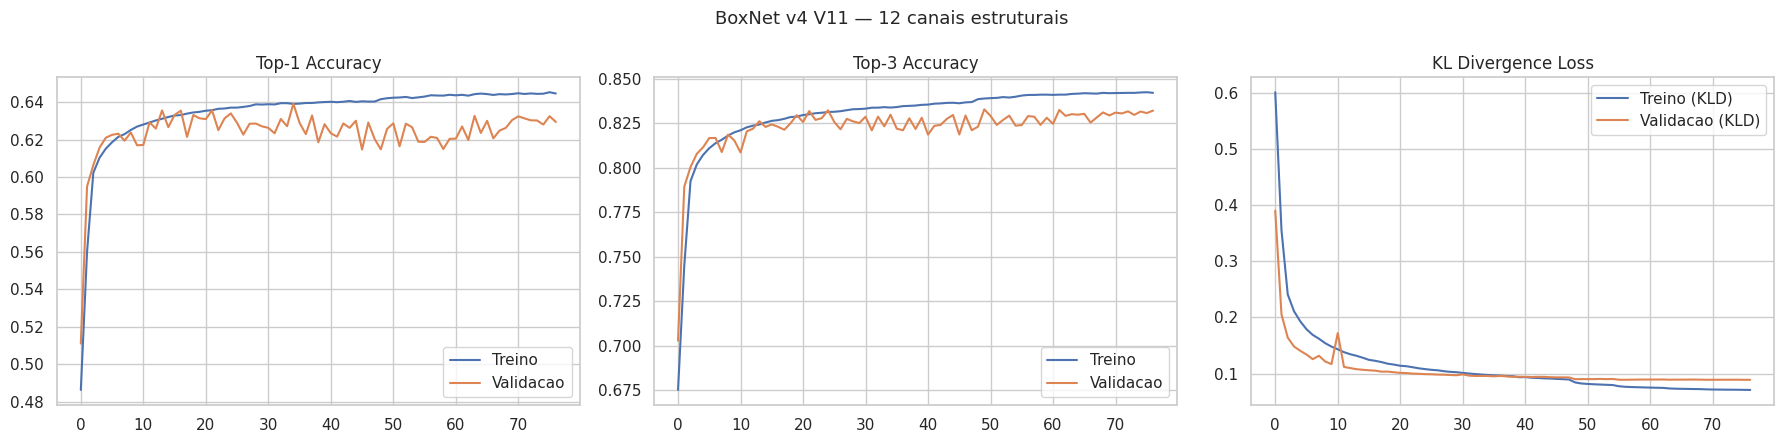

In [8]:
# =========================================================================
# 4. AVALIAÇÃO TEXTUAL
# =========================================================================

# 4.1 Métricas gerais (treino / val / teste)
def avalia_conjunto(nome, X_, y_soft_):
    with tf.device("/GPU:0"):
        m = model.evaluate(X_, y_soft_, verbose=0, return_dict=True)
    return {'Conjunto': nome, 'N': f"{X_.shape[0]:,}",
            'KLD Loss': round(m['loss'], 4), 'Top-1': round(m['accuracy'], 4),
            'Top-3': round(m['top3_acc'], 4), 'Top-5': round(m['top5_acc'], 4)}

# 4.2 OMA global
with tf.device("/GPU:0"):
    y_pred_prob = model.predict(X_test, verbose=0)
y_pred_idx  = y_pred_prob.argmax(axis=1)
max_scores_test = S_test.max(axis=1, keepdims=True)
eh_otimo        = (S_test == max_scores_test) & (S_test > -1e8)
pred_eh_otimo   = eh_otimo[np.arange(len(y_pred_idx)), y_pred_idx]
oma_global      = pred_eh_otimo.mean()
media_equiv     = eh_otimo.sum(axis=1).mean()

resultados = pd.DataFrame([
    avalia_conjunto('Treino',    X_train, y_train),
    avalia_conjunto('Validação', X_val,   y_val),
    avalia_conjunto('Teste',     X_test,  y_test),
]).set_index('Conjunto')

gap_top1 = resultados.loc['Treino', 'Top-1'] - resultados.loc['Validação', 'Top-1']
gap_kld  = resultados.loc['Validação', 'KLD Loss'] - resultados.loc['Treino', 'KLD Loss']

# 4.3 Métricas por fase
fases = [
    (0,  11, 'Abertura (0-11)'),
    (12, 17, '1a Metade (12-17)'),
    (18, 23, '2a Metade (18-23)'),
    (24, 28, 'Fase Quente (24-28)'),
    (29, 31, 'Final (29-31)'),
]
rows_fases = []
for lo, hi, nome in fases:
    mask = (tracos_test >= lo) & (tracos_test <= hi)
    if mask.sum() == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    argsorted = np.argsort(y_pred_prob[mask], axis=1)
    t3 = (argsorted[:, -3:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    t5 = (argsorted[:, -5:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    oma_f = pred_eh_otimo[mask].mean()
    rows_fases.append({'Fase': nome, 'N': int(mask.sum()),
                       'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}',
                       'Top-5': f'{t5:.1%}', 'OMA': f'{oma_f:.1%}'})

df_fases_report = pd.DataFrame(rows_fases).set_index('Fase')

# 4.4 Classification report
BORDAS = {
    'H_0_1', 'H_0_3', 'H_0_5', 'H_8_1', 'H_8_3', 'H_8_5',
    'V_1_0', 'V_3_0', 'V_5_0', 'V_7_0', 'V_1_6', 'V_3_6', 'V_5_6', 'V_7_6',
}
report = classification_report(
    y_test_idx, y_pred_idx,
    labels=list(range(num_classes)),
    target_names=[indice_para_rotulo[i] for i in range(num_classes)],
    digits=4, zero_division=0, output_dict=True,
)
por_classe = pd.DataFrame({
    rotulo: report[rotulo]
    for rotulo in [indice_para_rotulo[i] for i in range(num_classes)]
}).T
por_classe.index.name = 'Jogada'
por_classe = por_classe.sort_values('f1-score', ascending=False)
por_classe['Borda'] = por_classe.index.isin(BORDAS)

# --- Report: avaliação ---
_iniciar_secao('avaliacao')
_md_h(2, '4. Avaliação no Conjunto de Teste')
_md_h(3, '4.1 Resumo Geral')
_md_table(resultados, floatfmt='.4f')

rprint('| Métrica | Valor |')
rprint('|---------|-------|')
rprint(f'| Gap Top-1 (Treino − Val) | {gap_top1*100:+.2f} pp |')
rprint(f'| Gap KLD (Val − Treino) | {gap_kld:+.4f} |')
rprint(f'| **OMA global** | **{oma_global:.1%}** |')
rprint(f'| Média jogadas Minimax-equiv. | {media_equiv:.1f} |')
rprint()

_md_h(3, '4.2 Métricas por Fase')
_md_table(df_fases_report)

_md_h(3, '4.3 Classification Report')
rprint('| Métrica | Precision | Recall | F1 |')
rprint('|---------|-----------|--------|----|')
rprint(f'| Accuracy | — | — | {report["accuracy"]:.4f} |')
rprint(f'| Macro avg | {report["macro avg"]["precision"]:.4f} | {report["macro avg"]["recall"]:.4f} | {report["macro avg"]["f1-score"]:.4f} |')
rprint(f'| Weighted avg | {report["weighted avg"]["precision"]:.4f} | {report["weighted avg"]["recall"]:.4f} | {report["weighted avg"]["f1-score"]:.4f} |')
rprint()

_md_h(4, 'Top 10 jogadas (melhor F1)')
_md_table(por_classe.head(10)[['precision', 'recall', 'f1-score', 'support', 'Borda']])

_md_h(4, 'Bottom 5 jogadas (pior F1)')
_md_table(por_classe.tail(5)[['precision', 'recall', 'f1-score', 'support', 'Borda']])

rprint('*[Gráficos de curvas de aprendizado — ver notebook]*\n')
_md_sep()

# 4.5 Gráficos de treino (não capturados no relatório)
if history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].plot(history.history['accuracy'],     label='Treino')
    axes[0].plot(history.history['val_accuracy'], label='Validacao')
    axes[0].set_title('Top-1 Accuracy'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['top3_acc'],     label='Treino')
    axes[1].plot(history.history['val_top3_acc'], label='Validacao')
    axes[1].set_title('Top-3 Accuracy'); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(history.history['loss'],     label='Treino (KLD)')
    axes[2].plot(history.history['val_loss'], label='Validacao (KLD)')
    axes[2].set_title('KL Divergence Loss'); axes[2].legend(); axes[2].grid(True)
    plt.suptitle(f'BoxNet v4 V11 — {K} canais estruturais', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('Curvas de aprendizado indisponiveis (modelo carregado de checkpoint).')

In [ ]:
# =========================================================================
# 4.4 Métricas por qtd_cadeias_longas (grupos 0 / 1 / 2 / ≥3)
# =========================================================================
grupos_cadeias = [(0, 0, '0 cadeias'), (1, 1, '1 cadeia'), (2, 2, '2 cadeias'), (3, 99, '≥3 cadeias')]
rows_cadeias = []
for lo, hi, nome in grupos_cadeias:
    mask = (cadeias_test >= lo) & (cadeias_test <= hi)
    n = int(mask.sum())
    if n == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    argsorted = np.argsort(y_pred_prob[mask], axis=1)
    t3 = (argsorted[:, -3:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    oma_c = pred_eh_otimo[mask].mean()
    rows_cadeias.append({'Grupo': nome, 'N': n,
                         'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}', 'OMA': f'{oma_c:.1%}'})

df_cadeias = pd.DataFrame(rows_cadeias).set_index('Grupo')

_iniciar_secao('cadeias_metricas')
_md_h(3, '4.4 Métricas por qtd_cadeias_longas')
_md_table(df_cadeias)
_md_sep()

print(df_cadeias.to_string())

In [10]:
# =========================================================================
# 5. TABELA 1 — Presença de canal por fase do jogo (conjunto de TESTE)
# =========================================================================
canal_presente = canais_test.reshape(len(canais_test), 4 * 3, 12).any(axis=1)  # (N_test, 12)

rows_t1 = []
for lo, hi, nome in fases:
    mask = (tracos_test >= lo) & (tracos_test <= hi)
    n_fase = int(mask.sum())
    row = {'Fase': nome, 'N': n_fase}
    for ki, nome_canal in enumerate(NOMES_CANAIS_REF):
        row[nome_canal] = int(canal_presente[mask, ki].sum())
    rows_t1.append(row)

df_t1 = pd.DataFrame(rows_t1).set_index('Fase')
df_t1_pct = df_t1.copy()
for col in NOMES_CANAIS_REF:
    df_t1_pct[col] = (df_t1[col] / df_t1['N'] * 100).round(1)

_iniciar_secao('canais_fase')
_md_h(2, '5. Presença de Canais por Fase (%)')
rprint('*Percentual de amostras no conjunto de Teste com ao menos uma célula = 1 no canal*\n')
_md_table(df_t1_pct[list(NOMES_CANAIS_REF)], floatfmt='.1f')
_md_sep()


## 5. Presença de Canais por Fase (%)

*Percentual de amostras no conjunto de Teste com ao menos uma célula = 1 no canal*

| Fase                |   aresta_topo |   aresta_base |   aresta_esquerda |   aresta_direita |   caixa_fechada |   eh_grau3 |   eh_grau2 |   em_cadeia_curta |   em_cadeia_longa |   em_loop |   em_cadeia_aberta_uma_ponta |   paridade_cadeia_longa_impar |
|:--------------------|--------------:|--------------:|------------------:|-----------------:|----------------:|-----------:|-----------:|------------------:|------------------:|----------:|-----------------------------:|------------------------------:|
| Abertura (0-11)     |          93.9 |          93.9 |              94.0 |             94.0 |            11.0 |       18.8 |       87.5 |              24.7 |               3.3 |       0.0 |                          0.6 |                           3.3 |
| 1a Metade (12-17)   |         100.0 |         100.0 |             100.0 |            100.0 |            71.3 |  

In [11]:
# =========================================================================
# 6. TABELA 2 — Métricas por canal
# =========================================================================
rows_t2 = []
for ki, nome_canal in enumerate(NOMES_CANAIS_REF):
    mask = canal_presente[:, ki]
    n = int(mask.sum())
    if n == 0:
        rows_t2.append({'Canal': nome_canal, 'N': 0,
                        'Top-1': '—', 'Top-3': '—', 'Top-5': '—', 'OMA': '—'})
        continue
    y_pred_m  = y_pred_idx[mask]
    y_true_m  = y_test_idx[mask]
    y_pred_p  = y_pred_prob[mask]
    oma_m     = pred_eh_otimo[mask].mean()
    t1        = (y_pred_m == y_true_m).mean()
    argsorted = np.argsort(y_pred_p, axis=1)
    t3 = (argsorted[:, -3:] == y_true_m[:, np.newaxis]).any(axis=1).mean()
    t5 = (argsorted[:, -5:] == y_true_m[:, np.newaxis]).any(axis=1).mean()
    rows_t2.append({'Canal': nome_canal, 'N': n,
                    'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}',
                    'Top-5': f'{t5:.1%}', 'OMA': f'{oma_m:.1%}'})

df_t2 = pd.DataFrame(rows_t2).set_index('Canal')
_iniciar_secao('metricas_canal')
_md_h(2, '6. Métricas por Canal')
rprint('*Amostras do Teste onde o canal tem ao menos uma célula = 1*\n')
_md_table(df_t2)
_md_sep()


## 6. Métricas por Canal

*Amostras do Teste onde o canal tem ao menos uma célula = 1*

| Canal                       |       N | Top-1   | Top-3   | Top-5   | OMA    |
|:----------------------------|--------:|:--------|:--------|:--------|:-------|
| aresta_topo                 | 1228962 | 63.2%   | 84.0%   | 90.2%   | 97.4%  |
| aresta_base                 | 1228939 | 63.1%   | 84.0%   | 90.2%   | 97.4%  |
| aresta_esquerda             | 1229201 | 63.2%   | 84.1%   | 90.4%   | 97.4%  |
| aresta_direita              | 1229287 | 63.1%   | 84.0%   | 90.3%   | 97.4%  |
| caixa_fechada               |  709380 | 69.5%   | 90.7%   | 95.4%   | 98.9%  |
| eh_grau3                    |  539435 | 86.7%   | 100.0%  | 100.0%  | 100.0% |
| eh_grau2                    | 1177714 | 63.4%   | 84.8%   | 91.0%   | 97.3%  |
| em_cadeia_curta             |  565825 | 66.6%   | 88.0%   | 93.6%   | 97.5%  |
| em_cadeia_longa             |  447143 | 69.0%   | 89.9%   | 95.0%   | 99.1%  |
| em_loop           


## 7. Correlação Canal × Erro

*Erros (OMA=0): 32534 de 1258454 (2.6%) no conjunto de Teste*
*Delta positivo = canal sobrerrepresentado nos erros*

| Canal                       | Total (%)   | Em Erros (%)   |   Delta (pp) |
|:----------------------------|:------------|:---------------|-------------:|
| eh_grau2                    | 93.6%       | 98.6%          |       5.0000 |
| aresta_esquerda             | 97.7%       | 99.1%          |       1.4000 |
| aresta_direita              | 97.7%       | 99.0%          |       1.3000 |
| aresta_base                 | 97.7%       | 98.7%          |       1.1000 |
| aresta_topo                 | 97.7%       | 98.6%          |       1.0000 |
| em_cadeia_curta             | 45.0%       | 44.2%          |      -0.8000 |
| em_loop                     | 1.7%        | 0.1%           |      -1.5000 |
| em_cadeia_aberta_uma_ponta  | 12.7%       | 0.8%           |     -11.9000 |
| paridade_cadeia_longa_impar | 29.6%       | 11.7%          |     -17.

/tmp/ipykernel_5904/1137398439.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_corr_raw['Canal'], rotation=45, ha='right', fontsize=9)


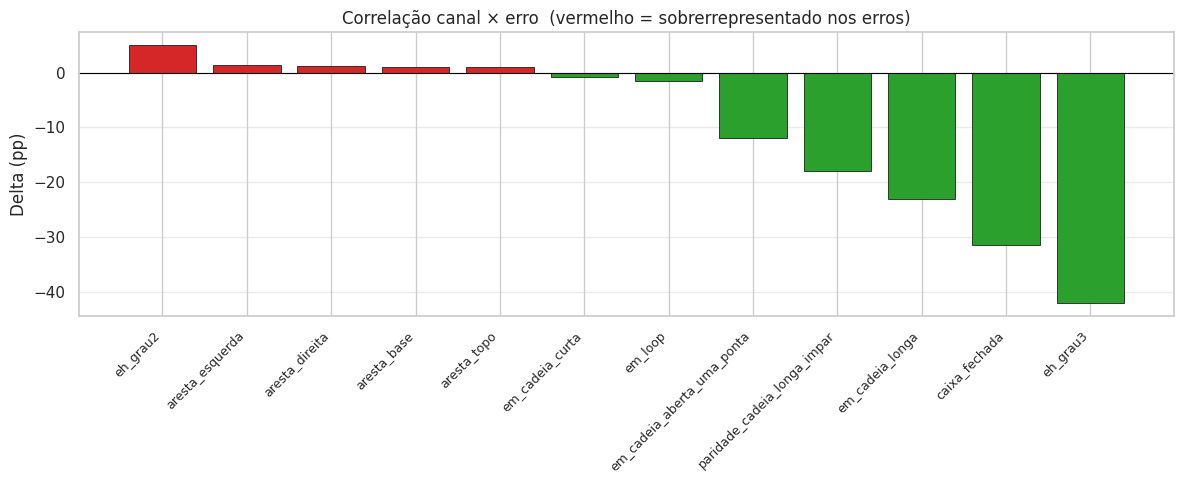

In [12]:
# =========================================================================
# 7. CORRELAÇÃO CANAL x ERRO
# =========================================================================
erros_mask = ~pred_eh_otimo
n_erros    = int(erros_mask.sum())
n_total    = len(erros_mask)

rows_corr = []
for ki, nome_canal in enumerate(NOMES_CANAIS_REF):
    taxa_total = float(canal_presente[:, ki].mean())
    taxa_erros = float(canal_presente[erros_mask, ki].mean()) if n_erros > 0 else 0.0
    delta      = (taxa_erros - taxa_total) * 100
    rows_corr.append({'Canal': nome_canal,
                      'Total (%)': f'{taxa_total:.1%}',
                      'Em Erros (%)': f'{taxa_erros:.1%}',
                      'Delta (pp)': f'{delta:+.1f}'})

df_corr_report = pd.DataFrame(rows_corr).sort_values(
    'Delta (pp)', ascending=False, key=lambda s: s.str.replace('+', '').astype(float)
).set_index('Canal')

_iniciar_secao('correlacao')
_md_h(2, '7. Correlação Canal × Erro')
rprint(f'*Erros (OMA=0): {n_erros} de {n_total} ({n_erros/n_total:.1%}) no conjunto de Teste*')
rprint('*Delta positivo = canal sobrerrepresentado nos erros*\n')
_md_table(df_corr_report, index=True)
_md_sep()

# Visualização (não capturada no relatório)
df_corr_raw = pd.DataFrame(rows_corr)
df_corr_raw['_delta'] = df_corr_raw['Delta (pp)'].str.replace('+', '').astype(float)
df_corr_raw = df_corr_raw.sort_values('_delta', ascending=False)
colors = ['#d62728' if float(d) > 0 else '#2ca02c' for d in df_corr_raw['_delta']]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_corr_raw['Canal'], df_corr_raw['_delta'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Delta (pp)')
ax.set_title('Correlação canal × erro  (vermelho = sobrerrepresentado nos erros)')
ax.set_xticklabels(df_corr_raw['Canal'], rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Performance por Fase (Numérico)

| Fase                |      N | Top-1   | Top-3   | Top-5   | OMA    |
|:--------------------|-------:|:--------|:--------|:--------|:-------|
| Abertura (0-11)     | 485556 | 49.4%   | 69.2%   | 78.5%   | 95.1%  |
| 1a Metade (12-17)   | 404916 | 67.2%   | 88.5%   | 94.5%   | 97.8%  |
| 2a Metade (18-23)   | 242659 | 74.2%   | 94.0%   | 96.9%   | 100.0% |
| Fase Quente (24-28) |  91075 | 65.4%   | 95.4%   | 98.9%   | 100.0% |
| Final (29-31)       |  34248 | 92.0%   | 100.0%  | 100.0%  | 100.0% |

*[Gráfico de barras por fase — ver notebook]*


---



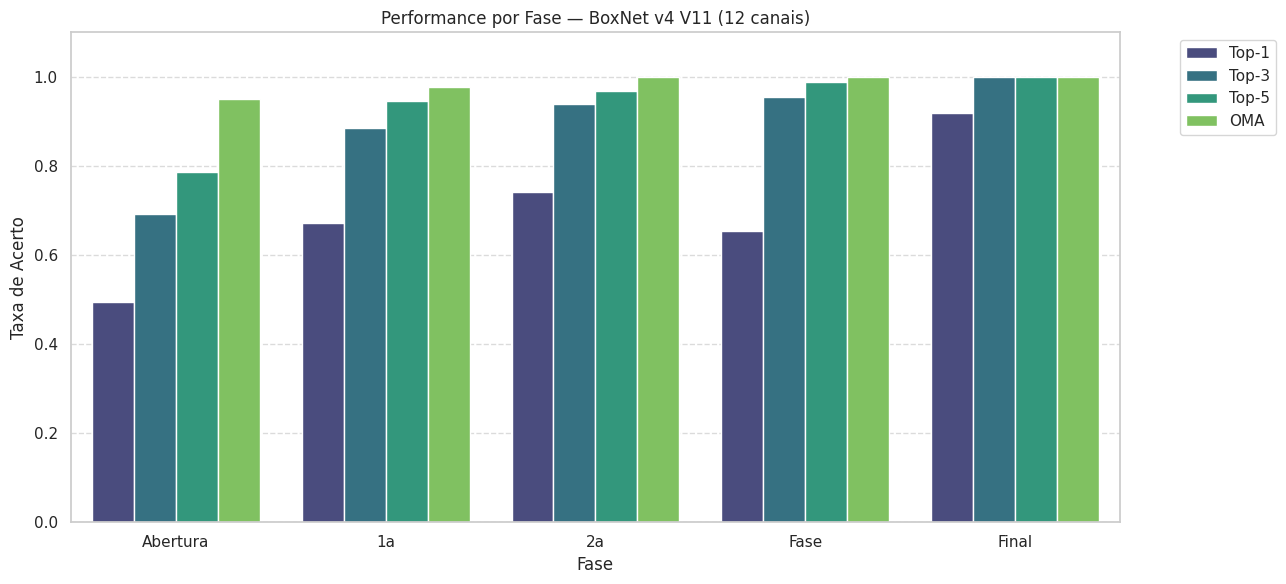

In [13]:
# =========================================================================
# 8. VISUALIZAÇÃO POR FASE (Top-1 / Top-3 / Top-5 / OMA)
# =========================================================================
dados_fases_chart = []
rows_fases_num = []

for lo, hi, nome in fases:
    mask = (tracos_test >= lo) & (tracos_test <= hi)
    if mask.sum() == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    argsorted = np.argsort(y_pred_prob[mask], axis=1)
    t3 = (argsorted[:, -3:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    t5 = (argsorted[:, -5:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    oma_f = pred_eh_otimo[mask].mean()
    fase_nome = nome.split(' ')[0]
    dados_fases_chart += [
        {'Fase': fase_nome, 'Metrica': 'Top-1', 'Acuracia': t1},
        {'Fase': fase_nome, 'Metrica': 'Top-3', 'Acuracia': t3},
        {'Fase': fase_nome, 'Metrica': 'Top-5', 'Acuracia': t5},
        {'Fase': fase_nome, 'Metrica': 'OMA',   'Acuracia': oma_f},
    ]
    rows_fases_num.append({'Fase': nome, 'N': int(mask.sum()),
                           'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}',
                           'Top-5': f'{t5:.1%}', 'OMA': f'{oma_f:.1%}'})

df_fases_num = pd.DataFrame(rows_fases_num).set_index('Fase')

_iniciar_secao('performance_fase')
_md_h(2, '8. Performance por Fase (Numérico)')
_md_table(df_fases_num)
rprint('*[Gráfico de barras por fase — ver notebook]*\n')
_md_sep()

# Gráfico (não capturado no relatório)
df_fases_chart = pd.DataFrame(dados_fases_chart)
plt.figure(figsize=(13, 6))
sns.barplot(data=df_fases_chart, x='Fase', y='Acuracia', hue='Metrica', palette='viridis')
plt.title(f'Performance por Fase — BoxNet v4 V11 ({K} canais)')
plt.ylim(0, 1.1)
plt.ylabel('Taxa de Acerto')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# =========================================================================
# 9. EXPORTACAO PARA TENSORFLOW LITE
# =========================================================================
with tf.device("/CPU:0"):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Sem quantizacao: float32 para maxima fidelidade (tamanho nao importa nesta fase).
# SELECT_TF_OPS permite converter o bloco de atencao (MultiHeadAttention usa einsum).
# O Interpreter Python (avaliacao) ja dispoe do delegate Flex.
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
tflite_model = converter.convert()

#nome_arquivo = f'pontinhos_pequeno_cnn_{K}canais_valloss.tflite'
nome_arquivo = f'pontinhos_pequeno_cnn_{K}canais_{EXPERIMENTO}.tflite'
tflite_path = os.path.join(RESULTADO_DIR, nome_arquivo)

with open(tflite_path, 'wb') as fout:
    fout.write(tflite_model)
print(f'Modelo salvo: {tflite_path} ({len(tflite_model)/1024:.1f} KB)')

# --- Report: exportacao ---
_iniciar_secao('exportacao')
_md_h(2, '9. Exportacao TFLite')
rprint('| Parametro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Arquivo | `{nome_arquivo}` |')
rprint(f'| Caminho | `{tflite_path}` |')
rprint(f'| Tamanho | {len(tflite_model)/1024:.1f} KB |')
rprint(f'| Quantizacao | Nenhuma (float32) |')
rprint()
_md_sep()

Saved artifact at '/tmp/tmpxgmpish_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4, 3, 12), dtype=tf.float32, name='canais_estruturais')
Output Type:
  TensorSpec(shape=(None, 31), dtype=tf.float32, name=None)
Captures:
  136780671152784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664948880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664946768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664950224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664950608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780671153936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664949264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664951376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664950992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136780664950800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1367806649

In [15]:
# =========================================================================
# 10. EXPORTAR RELATORIO PARA MARKDOWN
# =========================================================================
from datetime import datetime

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
#nome = f'pontinhos_pequeno_cnn_{K}canais_valloss_treinamento_{ts}.md'
nome = f'pontinhos_pequeno_cnn_{K}canais_{EXPERIMENTO}_treinamento_{ts}.md'
md_path = os.path.join(RESULTADO_DIR, nome)

with open(md_path, 'w', encoding='utf-8') as fmd:
    fmd.write(_report_buf.getvalue())
print(f'Relatorio salvo: {md_path} ({len(_report_buf.getvalue().encode())/1024:.1f} KB)')

Relatorio salvo: /content/drive/MyDrive/Arena Sagaz/CNN/resultados/pontinhos_pequeno_cnn_12canais_boxnetv4_oraculo_exato_refinamento2_8p3M_treinamento_20260601_185119.md (19.0 KB)
